## Laboratorium 6


### Zbiór danych

Zbiór danych znajduje się w katalogu `dataset/*`. Jest to zmodyfikowany zbiór danych znajdujący się pod adresem: <https://archive.ics.uci.edu/ml/datasets/leaf>.

### Przesyłanie zadań

Wszystkie pliki należy spakować archiwizatorem **zip** i przesłać za pośrednictwem platformy WIKAMP. Poniżej oczekiwana zawartość archiwum:

```
+-- 📂 [IMIE.NAZWISKO].zip
    +-- 📜 Lab[xx].ipynb
    +-- 📂 dataset
        +-- 📜 dataset.npz
        +-- 📜 ReadMe.pdf
```


### Zadanie 1

* Wybierz 10 pierwszych gatunków liści (będziesz je używać w kolejnych zadaniach), o identyfikatorach: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10.
* Znormalizuj dane w zakresie 0-1.
* Wybierz 2 najlepsze cechy.

### Zadanie 2

(kontynuacja zadania 1)

* Przeprowadź klasteryzację zbioru za pomocą metody [$k$-średnich](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).
* Korzystając z metody łokcia (sprawdź liczbę klastrów od 1 do 50) wybierz liczbę klastrów ($c$).
* Podziel zbiór na $c$ klastrów.
* Wyświetl wyniki klasteryzacji dla $c$ klastrów w postaci wykresu (punktowego), na którym zaprezentowane są klastry oraz centroidy w różnych kolorach.

> Dla chętnych: zaimplementować samodzielnie metodę k-średnich i wyświetlić kolejne kroki klasteryzacji.




In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [34]:
data = pd.read_csv('.\dataset\leaf.csv', header=None)
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,1,0.72694,1.4742,0.32396,0.98535,1.00000,0.835920,0.004657,0.003947,0.047790,0.127950,0.016108,0.005232,0.000275,1.17560
1,1,2,0.74173,1.5257,0.36116,0.98152,0.99825,0.798670,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
2,1,3,0.76722,1.5725,0.38998,0.97755,1.00000,0.808120,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
3,1,4,0.73797,1.4597,0.35376,0.97566,1.00000,0.816970,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
4,1,5,0.82301,1.7707,0.44462,0.97698,1.00000,0.754930,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,36,6,0.37522,1.1417,0.81725,0.68511,0.58772,0.125230,0.091860,1.535800,0.114880,0.208610,0.041703,0.013344,0.000820,2.02810
336,36,7,0.28064,1.0849,0.75319,0.72152,0.71404,0.136860,0.078996,1.135800,0.141220,0.218300,0.045488,0.012002,0.001515,2.40590
337,36,8,0.35344,1.0329,0.78147,0.70737,0.61579,0.135030,0.089763,1.466400,0.097663,0.207030,0.041101,0.016123,0.000453,1.69350
338,36,9,0.59988,1.1427,0.71532,0.66101,0.47544,0.157470,0.113370,2.339400,0.050389,0.135850,0.018121,0.006190,0.000265,1.15260


In [35]:
# choose first 10 classes
mask = data[0].isin([i for i in range(1,11)])
df = data[mask]
df.shape, df[0].unique()

((108, 16), array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int64))

In [36]:
X, y = df.drop(columns=[0,1]), df[0]
X.shape, y.shape

((108, 14), (108,))

In [37]:
# normalize the data
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X))

In [40]:
X

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.654949,0.076213,0.222468,0.985716,1.000000,0.986189,0.012483,0.000618,0.227267,0.374291,0.205925,0.192566,0.089124,0.383936
1,0.674458,0.084607,0.276358,0.974862,0.996664,0.928386,0.016500,0.000880,0.099469,0.220897,0.094599,0.093838,0.020689,0.185188
2,0.708081,0.092235,0.318108,0.963611,1.000000,0.943050,0.031692,0.002154,0.033148,0.085690,0.027283,0.023934,0.008038,0.080170
3,0.669498,0.073850,0.265638,0.958254,1.000000,0.956784,0.027711,0.001777,0.055068,0.118625,0.040963,0.033075,0.017755,0.140071
4,0.781670,0.124540,0.397262,0.961995,1.000000,0.860512,0.031491,0.002134,0.011736,0.036136,0.010035,0.009822,0.003115,0.038122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.304081,0.021189,0.084978,0.901545,0.953180,0.794423,0.243132,0.066003,0.604439,0.752762,0.627078,0.635369,0.216765,0.720431
104,0.420408,0.044056,0.206345,0.854046,0.983281,0.609702,0.265443,0.077760,0.790213,0.916864,0.867067,0.918375,0.283630,0.810218
105,0.120390,0.017293,0.145096,0.897605,0.986617,0.775367,0.352690,0.132938,0.561930,0.730904,0.597576,0.623557,0.204541,0.661762
106,0.204757,0.006601,0.091105,0.890520,0.949825,0.730382,0.329179,0.116628,0.702329,0.863405,0.785445,0.848367,0.292308,0.715909


In [44]:
# select 2 best features
X_ = SelectKBest(chi2, k=2).fit_transform(X, y)
X_.shape, y.shape

((108, 2), (108,))

### Zadanie 2

(kontynuacja zadania 1)

* Przeprowadź klasteryzację zbioru za pomocą metody [$k$-średnich](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).
* Korzystając z metody łokcia (sprawdź liczbę klastrów od 1 do 50) wybierz liczbę klastrów ($c$).
* Podziel zbiór na $c$ klastrów.
* Wyświetl wyniki klasteryzacji dla $c$ klastrów w postaci wykresu (punktowego), na którym zaprezentowane są klastry oraz centroidy w różnych kolorach.

> Dla chętnych: zaimplementować samodzielnie metodę k-średnich i wyświetlić kolejne kroki klasteryzacji.


In [46]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(X_)

In [ ]:
# (pl. inercja) - squared distance to the nearest cluster center for each sample
kmeans.inertia_

3.687018616259506

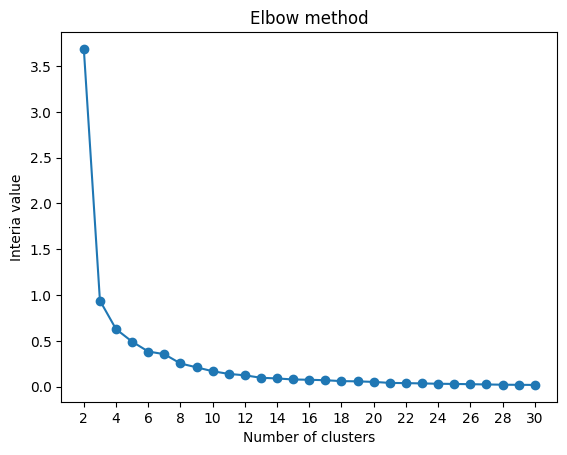

In [69]:
interias = []
clusters_list = [k for k in range(2,31)]
for k in clusters_list:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X_)
    interias.append(kmeans.inertia_)
    
# plt.figure(figsize=(10,8))
plt.plot(clusters_list, interias, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Interia value")
plt.title("Elbow method")
plt.xticks([i for i in range(2,31,2)])
plt.show()

We can observe that the elbow is at around 8-10 clusters.

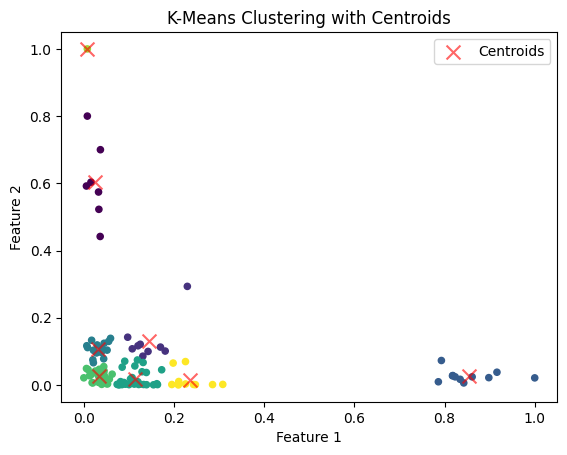

In [92]:
kmeans = KMeans(n_clusters=8, random_state=0).fit(X_)

plt.scatter(X_[:,0], X_[:,1], c=kmeans.labels_, s=20)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='x', color='red', s=100, alpha=0.6, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()